In [3]:
import pandas as pd
import numpy as np

In [ ]:
DATA_PATH = "kosts.csv"  
FILE_TYPE = "csv" 
TARGET_COLUMN = "target"  

if FILE_TYPE == "csv":
    df = pd.read_csv(DATA_PATH)
elif FILE_TYPE == "excel":
    df = pd.read_excel(DATA_PATH)
elif FILE_TYPE == "json":
    df = pd.read_json(DATA_PATH)
else:
    raise ValueError("FILE_TYPE must be 'csv', 'excel', or 'json'")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (764, 11)


,url,nama,harga_per_bulan,peraturan,fasilitas_kamar,fasilitas_umum,lahan_parkir,termasuk_listrik,kamar_mandi_dalam,kamar_mandi_luar,universitas_terdekat
0,https://mamikos.com/room/kost-sleman-kost-putr...,Kost Singgahsini UII Teko Tipe B Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Jendela,Kasur,Kursi,Lemari Baju,Meja...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260
1,https://mamikos.com/room/kost-kabupaten-sleman...,Kost Singgahsini Arkana Sadewa Tipe C Yogyakarta,1325000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472
2,https://mamikos.com/room/kost-kabupaten-sleman...,Kost Singgahsini Arkana Sadewa Tipe B Yogyakarta,1825000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472
3,https://mamikos.com/room/kost-kabupaten-sleman...,Kost Singgahsini UII Teko Tipe A Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260
4,https://mamikos.com/room/kost-sleman-kost-putr...,Kost Apik Kia Tipe A Wedomartani Yogyakarta,1050000,"Ada jam malam untuk tamu,Akses 24 Jam,Denda ke...","Bantal,Cermin,Guling,Jendela,Kasur,Kursi,Lemar...","Dapur,Kulkas,WiFi",Parkir Sepeda,ya,ya,tidak,Universitas Amikom Yogyakarta:3294


In [ ]:

# Basic inspection

print("Columns:")
print(df.columns.tolist())
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Duplicates per individual column
for col in df.columns:
    dup = df[col].duplicated().sum()
    if dup > 0:
        print(f"\n{col}: {dup} duplicates")

Columns:
['nama', 'harga_per_bulan', 'peraturan', 'fasilitas_kamar', 'fasilitas_umum', 'lahan_parkir', 'termasuk_listrik', 'kamar_mandi_dalam', 'kamar_mandi_luar', 'universitas_terdekat', 'kost_tipe']

Dtypes:
nama                    object
harga_per_bulan          int64
peraturan               object
fasilitas_kamar         object
fasilitas_umum          object
lahan_parkir            object
termasuk_listrik        object
kamar_mandi_dalam       object
kamar_mandi_luar        object
universitas_terdekat    object
kost_tipe               object
dtype: object

Missing values:
nama                     0
harga_per_bulan          0
peraturan               30
fasilitas_kamar          0
fasilitas_umum           1
lahan_parkir             0
termasuk_listrik         0
kamar_mandi_dalam        1
kamar_mandi_luar         1
universitas_terdekat     1
kost_tipe                0
dtype: int64

Duplicate rows: 689

nama: 690 duplicates

harga_per_bulan: 716 duplicates

peraturan: 714 duplicates

fasi

In [ ]:
# Drop irrelevant columns

df = df.drop(columns=["url"])

In [ ]:
# Separate kost_tipe based on the 'nama' column if it contains "TIPE A", "TIPE B", or "TIPE C"

def get_tipe(text):
    if pd.isna(text):
        return "notipe"
    for tipe in ["TIPE A", "TIPE B", "TIPE C"]:
        if tipe in str(text).upper():
            return tipe
    return "notipe"

df['kost_tipe'] = df['nama'].apply(get_tipe)   

In [29]:
df['kost_tipe'].value_counts()

kost_tipe
TIPE A    359
TIPE B    237
TIPE C    168
Name: count, dtype: int64

In [ ]:
# Cek "tipe kost" based on "harga_per_bulan"  

df = df.copy()

known = df[df["kost_tipe"].notna()].copy()
summary = (
    known.groupby("kost_tipe")["harga_per_bulan"]
    .agg(["min", "median", "max"])
    .sort_index()
)
print(summary)

              min     median      max
kost_tipe                            
TIPE A     458333  1210000.0  2525000
TIPE B     650000  1375000.0  2125000
TIPE C     500000  1825000.0  2025000


In [ ]:
# Replace "notipe" with NaN first
df["kost_tipe"] = df["kost_tipe"].replace("notipe", np.nan)

# Fill NaN with nearest tipe by median center
centers = {
    "TIPE A": 1210000,
    "TIPE B": 1450000,
    "TIPE C": 1825000
}

mask_kosttipe = df["kost_tipe"].isna()
df.loc[mask_kosttipe, "kost_tipe"] = df.loc[mask_kosttipe, "harga_per_bulan"].apply(
    lambda x: min(centers, key=lambda k: abs(x - centers[k]))
)   

In [ ]:
#Fill peraturan kost

df['peraturan'] = df['peraturan'].fillna('Tidak ada peraturan khusus')

In [39]:
df.head()

,nama,harga_per_bulan,peraturan,fasilitas_kamar,fasilitas_umum,lahan_parkir,termasuk_listrik,kamar_mandi_dalam,kamar_mandi_luar,universitas_terdekat,kost_tipe
0,Kost Singgahsini UII Teko Tipe B Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Jendela,Kasur,Kursi,Lemari Baju,Meja...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260,TIPE B
1,Kost Singgahsini Arkana Sadewa Tipe C Yogyakarta,1325000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472,TIPE C
2,Kost Singgahsini Arkana Sadewa Tipe B Yogyakarta,1825000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472,TIPE B
3,Kost Singgahsini UII Teko Tipe A Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260,TIPE A
4,Kost Apik Kia Tipe A Wedomartani Yogyakarta,1050000,"Ada jam malam untuk tamu,Akses 24 Jam,Denda ke...","Bantal,Cermin,Guling,Jendela,Kasur,Kursi,Lemar...","Dapur,Kulkas,WiFi",Parkir Sepeda,ya,ya,tidak,Universitas Amikom Yogyakarta:3294,TIPE A


In [40]:
df.isna().sum()

nama                    0
harga_per_bulan         0
peraturan               0
fasilitas_kamar         0
fasilitas_umum          1
lahan_parkir            0
termasuk_listrik        0
kamar_mandi_dalam       1
kamar_mandi_luar        1
universitas_terdekat    1
kost_tipe               0
dtype: int64

In [ ]:
# Preprocessing fasilitas_kamar, fasilitas_umum, and lahan_parkir columns into binary features
def to_binary(text, keywords):
    if pd.isna(text):
        return "tidak"
    txt = str(text).lower()
    return "ya" if any(k.lower() in txt for k in keywords) else "tidak"

# logic : If any of the keywords are found in the text (case-insensitive), return "ya", otherwise return "tidak", NaN return to "tidak", and all of value is ensure lowercase
# logic2 : make new columns for each keyword in fasilitas_kamar, fasilitas_umum, and lahan_parkir with binary values "ya" or "tidak"
 
# 1. Fasilitas kamar
df["fasilitas_kamar_ac"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["ac"])
)
df["fasilitas_kamar_kasur"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["kasur"])
)
df["fasilitas_kamar_lemari"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["lemari baju", "lemari"])
)
df["fasilitas_kamar_meja"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["meja"])
)
df["fasilitas_kamar_tv"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["tv"])
)
df["fasilitas_kamar_ventilasi"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["ventilasi"])
)
df["fasilitas_kamar_kipas_angin"] = df["fasilitas_kamar"].apply(
    lambda x: to_binary(x, ["kipas angin"])
)

# 2. Fasilitas umum
df["fasilitas_umum_wifi"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["wifi"])
)
df["fasilitas_umum_dapur"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["dapur"])
)
df["fasilitas_umum_kulkas"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["kulkas"])
)
df["fasilitas_umum_cctv"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["cctv"])
)
df["fasilitas_umum_penjaga_kos"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["penjaga kos", "penjaga"])
)
df["fasilitas_umum_laundry"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["r. cuci", "laundry"])
)
df["fasilitas_umum_ruang_tamu"] = df["fasilitas_umum"].apply(
    lambda x: to_binary(x, ["r. tamu", "ruang tamu"])
)

# 3. Lahan parkir
df["parkir_mobil"] = df["lahan_parkir"].apply(
    lambda x: to_binary(x, ["parkir mobil"])
)
df["parkir_motor"] = df["lahan_parkir"].apply(
    lambda x: to_binary(x, ["parkir motor"])
)
df["parkir_sepeda"] = df["lahan_parkir"].apply(
    lambda x: to_binary(x, ["parkir sepeda"])
)
df["ada_parkir"] = df["lahan_parkir"].apply(
    lambda x: to_binary(x, ["parkir"])
)

In [44]:
df.columns.tolist()

['nama',
 'harga_per_bulan',
 'peraturan',
 'fasilitas_kamar',
 'fasilitas_umum',
 'lahan_parkir',
 'termasuk_listrik',
 'kamar_mandi_dalam',
 'kamar_mandi_luar',
 'universitas_terdekat',
 'kost_tipe',
 'fasilitas_kamar_ac',
 'fasilitas_kamar_kasur',
 'fasilitas_kamar_lemari',
 'fasilitas_kamar_meja',
 'fasilitas_kamar_tv',
 'fasilitas_kamar_ventilasi',
 'fasilitas_kamar_kipas_angin',
 'fasilitas_umum_wifi',
 'fasilitas_umum_dapur',
 'fasilitas_umum_kulkas',
 'fasilitas_umum_cctv',
 'fasilitas_umum_penjaga_kos',
 'fasilitas_umum_laundry',
 'fasilitas_umum_ruang_tamu',
 'parkir_mobil',
 'parkir_motor',
 'parkir_sepeda',
 'ada_parkir']

In [45]:
df.isna().sum()

nama                           0
harga_per_bulan                0
peraturan                      0
fasilitas_kamar                0
fasilitas_umum                 1
lahan_parkir                   0
termasuk_listrik               0
kamar_mandi_dalam              1
kamar_mandi_luar               1
universitas_terdekat           1
kost_tipe                      0
fasilitas_kamar_ac             0
fasilitas_kamar_kasur          0
fasilitas_kamar_lemari         0
fasilitas_kamar_meja           0
fasilitas_kamar_tv             0
fasilitas_kamar_ventilasi      0
fasilitas_kamar_kipas_angin    0
fasilitas_umum_wifi            0
fasilitas_umum_dapur           0
fasilitas_umum_kulkas          0
fasilitas_umum_cctv            0
fasilitas_umum_penjaga_kos     0
fasilitas_umum_laundry         0
fasilitas_umum_ruang_tamu      0
parkir_mobil                   0
parkir_motor                   0
parkir_sepeda                  0
ada_parkir                     0
dtype: int64

In [47]:
df[df['fasilitas_umum'].isna()].iloc[0]

nama                            Kost Singgahsini Pramesthi UPN Tipe A Yogyakarta
harga_per_bulan                                                          1525000
peraturan                      Ada jam malam untuk tamu,Akses 24 Jam,Denda ke...
fasilitas_kamar                AC,Bantal,Guling,Jendela,Kasur,Kulkas,Lemari B...
fasilitas_umum                                                               NaN
lahan_parkir                                          Parkir Mobil,Parkir Sepeda
termasuk_listrik                                                              ya
kamar_mandi_dalam                                                            NaN
kamar_mandi_luar                                                             NaN
universitas_terdekat                          Universitas Negeri Yogyakarta:1671
kost_tipe                                                                 TIPE A
fasilitas_kamar_ac                                                            ya
fasilitas_kamar_kasur       

In [48]:
df['fasilitas_umum'] = df['fasilitas_umum'].fillna('Tidak ada fasilitas umum')
df['kamar_mandi_luar'] = df['kamar_mandi_luar'].fillna('Tidak ada kamar mandi luar')
df['kamar_mandi_dalam'] = df['kamar_mandi_dalam'].fillna('Tidak ada kamar mandi dalam')
df["universitas_terdekat"] = df["universitas_terdekat"].fillna("Tidak ada universitas terdekat")

In [50]:
df.dtypes

nama                           object
harga_per_bulan                 int64
peraturan                      object
fasilitas_kamar                object
fasilitas_umum                 object
lahan_parkir                   object
termasuk_listrik               object
kamar_mandi_dalam              object
kamar_mandi_luar               object
universitas_terdekat           object
kost_tipe                      object
fasilitas_kamar_ac             object
fasilitas_kamar_kasur          object
fasilitas_kamar_lemari         object
fasilitas_kamar_meja           object
fasilitas_kamar_tv             object
fasilitas_kamar_ventilasi      object
fasilitas_kamar_kipas_angin    object
fasilitas_umum_wifi            object
fasilitas_umum_dapur           object
fasilitas_umum_kulkas          object
fasilitas_umum_cctv            object
fasilitas_umum_penjaga_kos     object
fasilitas_umum_laundry         object
fasilitas_umum_ruang_tamu      object
parkir_mobil                   object
parkir_motor

In [52]:
df

,nama,harga_per_bulan,peraturan,fasilitas_kamar,fasilitas_umum,lahan_parkir,termasuk_listrik,kamar_mandi_dalam,kamar_mandi_luar,universitas_terdekat,...,fasilitas_umum_dapur,fasilitas_umum_kulkas,fasilitas_umum_cctv,fasilitas_umum_penjaga_kos,fasilitas_umum_laundry,fasilitas_umum_ruang_tamu,parkir_mobil,parkir_motor,parkir_sepeda,ada_parkir
0,Kost Singgahsini UII Teko Tipe B Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Jendela,Kasur,Kursi,Lemari Baju,Meja...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
1,Kost Singgahsini Arkana Sadewa Tipe C Yogyakarta,1325000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
2,Kost Singgahsini Arkana Sadewa Tipe B Yogyakarta,1825000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
3,Kost Singgahsini UII Teko Tipe A Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
4,Kost Apik Kia Tipe A Wedomartani Yogyakarta,1050000,"Ada jam malam untuk tamu,Akses 24 Jam,Denda ke...","Bantal,Cermin,Guling,Jendela,Kasur,Kursi,Lemar...","Dapur,Kulkas,WiFi",Parkir Sepeda,ya,ya,tidak,Universitas Amikom Yogyakarta:3294,...,ya,ya,tidak,tidak,tidak,tidak,tidak,tidak,ya,ya
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
759,Kost Apik Roemah Aisyah Tipe A Yogyakarta,625000,"Ada jam malam untuk tamu,Akses 24 Jam,Denda ke...","Bantal,Cermin,Guling,Jendela,Kasur,Kipas Angin...","Dapur,Jemuran,K. Mandi Luar,Penjaga Kos,R. Jem...",Parkir Motor & Sepeda,tidak,tidak,ya,Sekolah Tinggi Ilmu Kesehatan Aisyiyah Yogyaka...,...,ya,tidak,tidak,ya,tidak,ya,tidak,ya,tidak,ya
760,Kost Apik Pondok Trio Tipe B Maguwoharjo Yogya...,775000,"Ada jam malam,Dilarang bawa hewan,Lawan jenis ...","Bantal,Jendela,Kasur,Lemari Baju","Dapur,K. Mandi Luar,Penjaga Kos,R. Cuci,R. Tam...","Parkir Mobil,Parkir Motor & Sepeda,Parkir Sepeda",tidak,ya,tidak,Universitas Pembangunan Nasional Veteran Yogya...,...,ya,tidak,tidak,ya,ya,ya,ya,ya,ya,ya
761,Kost Singgahsini House of Dyandra Tipe A Yogya...,1825000,"Ada jam malam,Ada jam malam untuk tamu,Denda k...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","CCTV,Dapur,Dispenser,Jemuran,Kulkas,Penjaga Ko...","Parkir Mobil,Parkir Motor & Sepeda",ya,ya,tidak,Universitas Amikom Yogyakarta:509,...,ya,ya,ya,ya,ya,ya,ya,ya,tidak,ya
762,Kost Singgahsini Wulandari Tipe C Wedomartani ...,1325000,"Ada jam malam,Denda kerusakan barang kos,Dilar...","AC,Jendela,Kasur,Kursi,Lemari Baju,Meja","CCTV,Dapur,Mushola,Penjaga Kos,R. Jemur,R. Mak...","Parkir Mobil,Parkir Motor & Sepeda",ya,ya,tidak,Universitas Amikom Yogyakarta:1662,...,ya,tidak,ya,ya,tidak,ya,ya,ya,tidak,ya


In [53]:
df["universitas_terdekat"].unique()

array(['Universitas Islam Indonesia:1260',
       'Universitas Islam Indonesia:3472',
       'Universitas Amikom Yogyakarta:3294',
       'Universitas Islam Indonesia:754',
       'Sekolah Tinggi Ilmu Kesehatan Aisyiyah Yogyakarta:658',
       'Universitas Islam Indonesia:2255', 'Universitas Gadjah Mada:2044',
       'Universitas Atma Jaya Yogyakarta:532',
       'Universitas Islam Indonesia:1578',
       'Universitas Pembangunan Nasional Veteran Yogyakarta:1405',
       'Akademi Maritim Yogyakarta:2579',
       'Universitas Islam Indonesia:900',
       'Universitas Islam Indonesia:1530',
       'Universitas Amikom Yogyakarta:689',
       'Universitas Pembangunan Nasional Veteran Yogyakarta:450',
       'Universitas Islam Indonesia:1390',
       'Universitas Atma Jaya Yogyakarta:1344',
       'Akademi Keperawatan Panti Rapih Yogyakarta:412',
       'Tidak ada universitas terdekat',
       'Universitas Negeri Yogyakarta:1061',
       'Universitas Islam Indonesia:726',
       'Universita

In [51]:
df.to_csv("preprocessed_dataset.csv", index=False)

In [54]:
pd.read_csv("preprocessed_dataset.csv").head()

,nama,harga_per_bulan,peraturan,fasilitas_kamar,fasilitas_umum,lahan_parkir,termasuk_listrik,kamar_mandi_dalam,kamar_mandi_luar,universitas_terdekat,...,fasilitas_umum_dapur,fasilitas_umum_kulkas,fasilitas_umum_cctv,fasilitas_umum_penjaga_kos,fasilitas_umum_laundry,fasilitas_umum_ruang_tamu,parkir_mobil,parkir_motor,parkir_sepeda,ada_parkir
0,Kost Singgahsini UII Teko Tipe B Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Jendela,Kasur,Kursi,Lemari Baju,Meja...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
1,Kost Singgahsini Arkana Sadewa Tipe C Yogyakarta,1325000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
2,Kost Singgahsini Arkana Sadewa Tipe B Yogyakarta,1825000,"Ada jam malam untuk tamu,Akses 24 Jam,Boleh pa...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Dapur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:3472,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
3,Kost Singgahsini UII Teko Tipe A Candiwinangun...,1250000,"Ada jam malam,Ada jam malam untuk tamu,Dilaran...","AC,Bantal,Cermin,Jendela,Kasur,Kursi,Lemari Ba...","Balcon,Dapur,R. Jemur,R. Tamu,WiFi","Parkir Mobil,Parkir Sepeda",ya,ya,tidak,Universitas Islam Indonesia:1260,...,ya,tidak,tidak,tidak,tidak,ya,ya,tidak,ya,ya
4,Kost Apik Kia Tipe A Wedomartani Yogyakarta,1050000,"Ada jam malam untuk tamu,Akses 24 Jam,Denda ke...","Bantal,Cermin,Guling,Jendela,Kasur,Kursi,Lemar...","Dapur,Kulkas,WiFi",Parkir Sepeda,ya,ya,tidak,Universitas Amikom Yogyakarta:3294,...,ya,ya,tidak,tidak,tidak,tidak,tidak,tidak,ya,ya


In [15]:
dpr = pd.read_csv("preprocessed_dataset.csv")

# numerik
dpr["harga_per_bulan"] = pd.to_numeric(dpr["harga_per_bulan"], errors="coerce")

# ordered categorical
dpr["kost_tipe"] = pd.Categorical(
    dpr["kost_tipe"],
    categories=["TIPE A", "TIPE B", "TIPE C"],
    ordered=True
)

# ya/tidak -> bool
yes_no_cols = [
    "termasuk_listrik",
    "kamar_mandi_dalam",
    "kamar_mandi_luar",
    "fasilitas_kamar_ac",
    "fasilitas_kamar_kasur",
    "fasilitas_kamar_lemari",
    "fasilitas_kamar_meja",
    "fasilitas_kamar_tv",
    "fasilitas_kamar_ventilasi",
    "fasilitas_kamar_kipas_angin",
    "fasilitas_umum_wifi",
    "fasilitas_umum_dapur",
    "fasilitas_umum_kulkas",
    "fasilitas_umum_cctv",
    "fasilitas_umum_penjaga_kos",
    "fasilitas_umum_laundry",
    "fasilitas_umum_ruang_tamu",
    "parkir_mobil",
    "parkir_motor",
    "parkir_sepeda",
    "ada_parkir"
]

for col in yes_no_cols:
    dpr[col] = dpr[col].astype(str).str.strip().str.lower()
    dpr[col] = dpr[col].map({
        "ya": True,
        "yes": True,
        "tidak": False,
        "no": False,
        "true": True,
        "false": False
    })

# text tetap text
for col in ["nama", "peraturan", "fasilitas_kamar", "fasilitas_umum", "lahan_parkir", "universitas_terdekat"]:
    dpr[col] = dpr[col].astype(str)

# tampilkan tipe data final
print(dpr.dtypes)

nama                             object
harga_per_bulan                   int64
peraturan                        object
fasilitas_kamar                  object
fasilitas_umum                   object
lahan_parkir                     object
termasuk_listrik                   bool
kamar_mandi_dalam                object
kamar_mandi_luar                 object
universitas_terdekat             object
kost_tipe                      category
fasilitas_kamar_ac                 bool
fasilitas_kamar_kasur              bool
fasilitas_kamar_lemari             bool
fasilitas_kamar_meja               bool
fasilitas_kamar_tv                 bool
fasilitas_kamar_ventilasi          bool
fasilitas_kamar_kipas_angin        bool
fasilitas_umum_wifi                bool
fasilitas_umum_dapur               bool
fasilitas_umum_kulkas              bool
fasilitas_umum_cctv                bool
fasilitas_umum_penjaga_kos         bool
fasilitas_umum_laundry             bool
fasilitas_umum_ruang_tamu          bool


In [18]:
# 1. rata-rata harga per tipe
dpr.groupby("kost_tipe", observed=False)["harga_per_bulan"].mean()


kost_tipe
TIPE A    1.153821e+06
TIPE B    1.481730e+06
TIPE C    1.590387e+06
Name: harga_per_bulan, dtype: float64

In [ ]:
# 2. proporsi fasilitas
dpr["fasilitas_kamar_ac"].mean()

0.7342931937172775

In [7]:
# 3. hubungan parkir dengan harga
dpr.groupby("ada_parkir")["harga_per_bulan"].mean()

ada_parkir
True    1.351540e+06
Name: harga_per_bulan, dtype: float64

In [8]:
# 4. jumlah kos per tipe
dpr["kost_tipe"].value_counts()

kost_tipe
TIPE A    359
TIPE B    237
TIPE C    168
Name: count, dtype: int64

In [10]:
# 5. top fitur yang umum
feature_cols = dpr.filter(regex=r"^(fasilitas_|parkir_)").select_dtypes(include=['bool']).columns.tolist()
summary = {col: dpr[col].mean() for col in feature_cols}
print(sorted(summary.items(), key=lambda x: x[1], reverse=True))


[('fasilitas_umum_wifi', 0.9973821989528796), ('fasilitas_kamar_kasur', 0.9856020942408377), ('fasilitas_kamar_lemari', 0.9450261780104712), ('fasilitas_umum_ruang_tamu', 0.9162303664921466), ('parkir_mobil', 0.8259162303664922), ('fasilitas_umum_dapur', 0.7722513089005235), ('fasilitas_kamar_ac', 0.7342931937172775), ('fasilitas_kamar_meja', 0.6924083769633508), ('fasilitas_umum_penjaga_kos', 0.650523560209424), ('parkir_motor', 0.6387434554973822), ('parkir_sepeda', 0.5301047120418848), ('fasilitas_kamar_tv', 0.41492146596858637), ('fasilitas_kamar_ventilasi', 0.4109947643979058), ('fasilitas_umum_cctv', 0.4109947643979058), ('fasilitas_umum_kulkas', 0.38612565445026176), ('fasilitas_umum_laundry', 0.2513089005235602), ('fasilitas_kamar_kipas_angin', 0.060209424083769635)]


Statistik harga per tipe:
            count     min     median       mean      max
kost_tipe                                              
TIPE A       359  458333  1210000.0  1153821.0  2525000
TIPE B       237  650000  1375000.0  1481730.0  2125000
TIPE C       168  500000  1825000.0  1590387.0  2025000


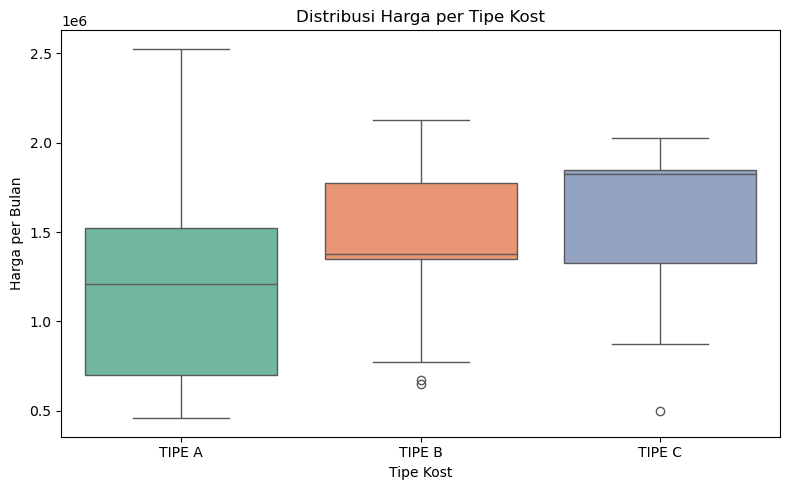

<Figure size 1400x700 with 0 Axes>

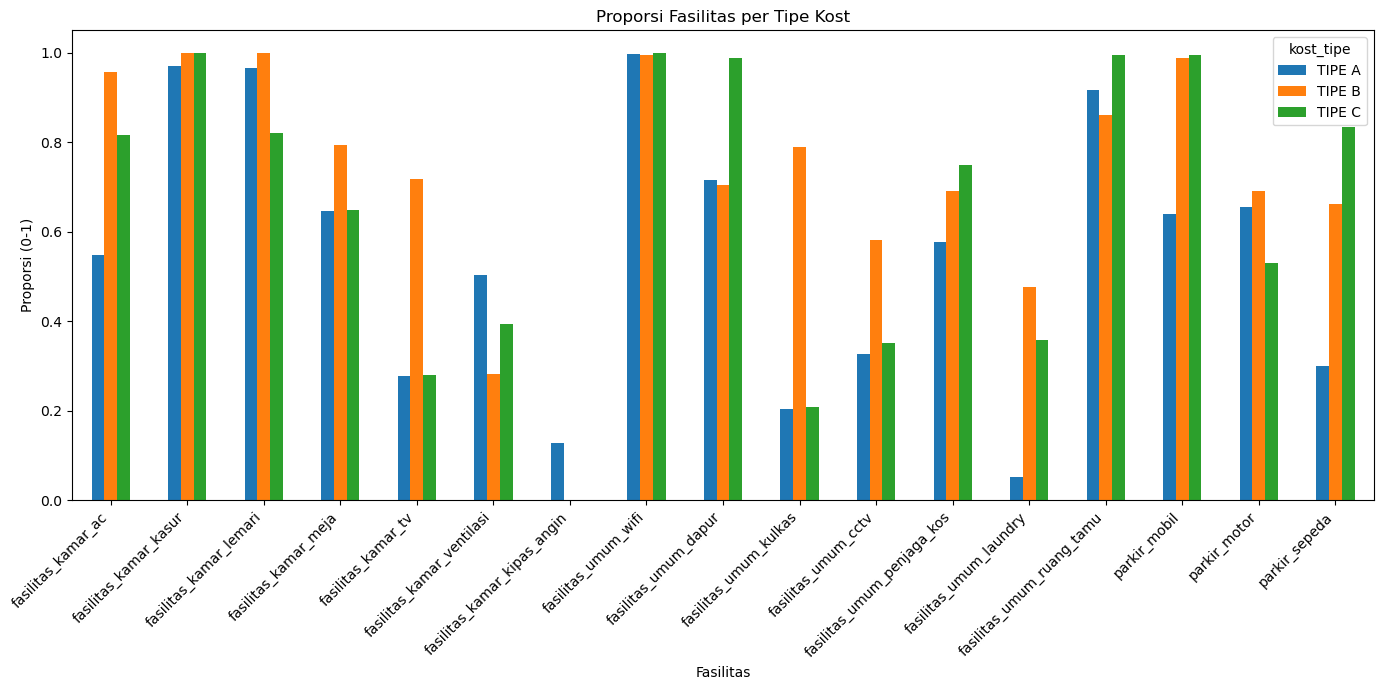


Fasilitas paling umum:
fasilitas_umum_wifi: 0.997
fasilitas_kamar_kasur: 0.986
fasilitas_kamar_lemari: 0.945
fasilitas_umum_ruang_tamu: 0.916
parkir_mobil: 0.826
fasilitas_umum_dapur: 0.772
fasilitas_kamar_ac: 0.734
fasilitas_kamar_meja: 0.692
fasilitas_umum_penjaga_kos: 0.651
parkir_motor: 0.639

Rata-rata harga berdasarkan ada parkir:
                     mean     median  count
ada_parkir                                
True        1.351540e+06  1375000.0    764


In [23]:
# EDA lanjutan untuk analisis harga dan fasilitas per tipe kos
import matplotlib.pyplot as plt
import seaborn as sns

# 1) statistik harga per tipe
summary_harga = (
    dpr.groupby("kost_tipe", observed=False)["harga_per_bulan"]
    .agg(["count", "min", "median", "mean", "max"])
    .round(0)
)
print("Statistik harga per tipe:\n", summary_harga)

# 2) distribusi harga per tipe
plt.figure(figsize=(8, 5))
sns.boxplot(data=dpr, x="kost_tipe", y="harga_per_bulan", palette="Set2",hue="kost_tipe")
plt.title("Distribusi Harga per Tipe Kost")
plt.xlabel("Tipe Kost")
plt.ylabel("Harga per Bulan")
plt.tight_layout()
plt.show()

# 3) proporsi fasilitas umum per tipe kost
feature_cols = dpr.filter(regex=r"^(fasilitas_|parkir_)").select_dtypes(include=['bool']).columns.tolist()
feature_by_tipe = dpr.groupby("kost_tipe", observed=False)[feature_cols].mean().T

plt.figure(figsize=(14, 7))
feature_by_tipe.plot(kind="bar", figsize=(14, 7))
plt.title("Proporsi Fasilitas per Tipe Kost")
plt.ylabel("Proporsi (0-1)")
plt.xlabel("Fasilitas")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4) fasilitas paling umum secara keseluruhan
fac_summary = {col: round(float(dpr[col].mean()), 3) for col in feature_cols}
print("\nFasilitas paling umum:")
for key, val in sorted(fac_summary.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"{key}: {val}")

# 5) rata-rata harga untuk yang punya parkir dan yang tidak
parkir_summary = dpr.groupby("ada_parkir")["harga_per_bulan"].agg(["mean", "median", "count"])
print("\nRata-rata harga berdasarkan ada parkir:\n", parkir_summary)


In [27]:
dpr = pd.read_csv("preprocessed_dataset.csv")
dpr["harga_per_bulan"] = pd.to_numeric(dpr["harga_per_bulan"], errors="coerce")

# tipe diurutkan A -> B -> C
dpr["kost_tipe"] = pd.Categorical(
    dpr["kost_tipe"],
    categories=["TIPE A", "TIPE B", "TIPE C"],
    ordered=True
)

# konversi ya/tidak jadi boolean
yes_no_cols = [
    "termasuk_listrik", "kamar_mandi_dalam", "kamar_mandi_luar",
    "fasilitas_kamar_ac", "fasilitas_kamar_kasur", "fasilitas_kamar_lemari",
    "fasilitas_kamar_meja", "fasilitas_kamar_tv", "fasilitas_kamar_ventilasi",
    "fasilitas_kamar_kipas_angin", "fasilitas_umum_wifi", "fasilitas_umum_dapur",
    "fasilitas_umum_kulkas", "fasilitas_umum_cctv", "fasilitas_umum_penjaga_kos",
    "fasilitas_umum_laundry", "fasilitas_umum_ruang_tamu",
    "parkir_mobil", "parkir_motor", "parkir_sepeda", "ada_parkir"
]

for col in yes_no_cols:
    dpr[col] = dpr[col].astype(str).str.strip().str.lower()
    dpr[col] = dpr[col].map({
        "ya": True, "yes": True,
        "tidak": False, "no": False,
        "true": True, "false": False
    })

# bobot fasilitas
weights = {
    "termasuk_listrik": 2,
    "kamar_mandi_dalam": 2,
    "kamar_mandi_luar": 1.5,
    "fasilitas_kamar_ac": 2.5,
    "fasilitas_kamar_kasur": 2.5,
    "fasilitas_kamar_lemari": 1.8,
    "fasilitas_kamar_meja": 1.5,
    "fasilitas_kamar_tv": 1.5,
    "fasilitas_kamar_ventilasi": 1.2,
    "fasilitas_kamar_kipas_angin": 1.0,
    "fasilitas_umum_wifi": 2.5,
    "fasilitas_umum_dapur": 1.8,
    "fasilitas_umum_kulkas": 1.8,
    "fasilitas_umum_cctv": 1.2,
    "fasilitas_umum_penjaga_kos": 1.0,
    "fasilitas_umum_laundry": 1.0,
    "fasilitas_umum_ruang_tamu": 1.2,
    "parkir_mobil": 1.5,
    "parkir_motor": 1.2,
    "parkir_sepeda": 0.8,
    "ada_parkir": 1.0
}

feature_cols = [c for c in dpr.columns if c in weights]
dpr["facility_score"] = dpr[feature_cols].dot(pd.Series(weights))

# harga relatif dalam tipe yang sama
min_price = dpr.groupby("kost_tipe", observed=False)["harga_per_bulan"].transform("min")
max_price = dpr.groupby("kost_tipe", observed=False)["harga_per_bulan"].transform("max")

dpr["price_score"] = 1 - (
    (dpr["harga_per_bulan"] - min_price) /
    (max_price - min_price + 1e-9)
)

# total score
dpr["overall_score"] = dpr["facility_score"] + dpr["price_score"] * 5

best_by_type = (
    dpr.sort_values(["kost_tipe", "overall_score"], ascending=[True, False])
       .groupby("kost_tipe", as_index=False, observed=False)
       .head(1)
       [["kost_tipe", "nama", "harga_per_bulan", "overall_score"]]
)

print(best_by_type)

   kost_tipe                                         nama  harga_per_bulan  \
33    TIPE A  Kost Singgahsini Cawingun Tipe A Yogyakarta          1325000   
51    TIPE B   Kost Syariah Griya Almira 1 Ngaglik Sleman          1350000   
34    TIPE C                Kost Griya Adhya Depok Sleman          1800000   

   overall_score  
33     29.903225  
51     32.627119  
34     28.537705  
